In [23]:
from langgraph.graph import StateGraph, START,END 
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [24]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [25]:
class batsmanstate(TypedDict):
    
    run: int 
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float

In [26]:
graph = StateGraph(batsmanstate)

In [27]:
def calculate_sr(state: batsmanstate) -> batsmanstate:
    
    strike_rate = (state["run"]/state["balls"])*100
    return {"strike_rate":strike_rate}

In [28]:
def calculate_boundary_percentage(state: batsmanstate) -> batsmanstate:

    boundary_percentage = (state['fours']+state['sixes'])/state["balls"]
    return {"boundary_percentage":boundary_percentage}

In [29]:
def calculate_balls_per_boundary(state: batsmanstate) -> batsmanstate:

    balls_per_boundary = state["balls"]/(state['fours']+state['sixes'])
    return {"balls_per_boundary":balls_per_boundary}

In [30]:
graph.add_node("strike rate",calculate_sr)
graph.add_node("boundary percentage",calculate_boundary_percentage)
graph.add_node("balls per boundary",calculate_balls_per_boundary)

In [31]:
graph.add_edge(START,"strike rate")
graph.add_edge(START,"boundary percentage")
graph.add_edge(START,"balls per boundary")
graph.add_edge("strike rate",END)
graph.add_edge("boundary percentage",END)
graph.add_edge("balls per boundary",END)

In [32]:
workflow = graph.compile()

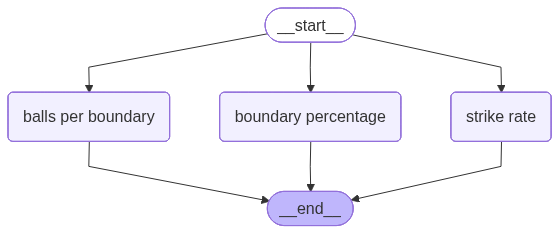

In [33]:
workflow

In [34]:
initial_state = {
    "run": 100, 
    "balls": 200,
    "fours": 10,
    "sixes": 10
}

final_state = workflow.invoke(initial_state)

In [35]:
print(final_state)

{'run': 100, 'balls': 200, 'fours': 10, 'sixes': 10, 'strike_rate': 50.0, 'balls_per_boundary': 10.0, 'boundary_percentage': 0.1}
